# Text Preproscessing 

# Import  Eseention liberis

In [1]:
import pandas as pd
import nltk
import matplotlib.pyplot as plt
from wordcloud import WordCloud 
from sklearn.model_selection import train_test_split
from nltk.stem import WordNetLemmatizer
from nltk.corpus import stopwords


# Load the Clean data

In [2]:
data = pd.read_csv('../Data/cleaned_data.csv',encoding='latin-1')
data.head()

,target,messages,num_characters
0,0,"Go until jurong point, crazy.. Available only ...",111
1,0,Ok lar... Joking wif u oni...,29
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155
3,0,U dun say so early hor... U c already then say...,49
4,0,"Nah I don't think he goes to usf, he lives aro...",61


In [3]:
lemmatizer = WordNetLemmatizer()
stop_words = set(stopwords.words('english'))


In [4]:
def text_preproceser(text):
    # 1. lowercase
    text = text.lower()
    
    # 2. tokenization
    words = nltk.word_tokenize(text)
    
    # 3. keep only alphanumeric
    words = [word for word in words if word.isalnum()]
    
    # 4. remove stopwords
    words = [word for word in words if word not in stop_words]
    
    # 5. lemmatization
    words = [lemmatizer.lemmatize(word) for word in words]
    
    return " ".join(words)

In [5]:
# get a text
data['messages'][8]

'WINNER!! As a valued network customer you have been selected to receivea Ã¥Â£900 prize reward! To claim call 09061701461. Claim code KL341. Valid 12 hours only.'

In [6]:
# chek 
test = 'WINNER!! As a valued network customer you have been selected to receivea Ã¥Â£900 prize reward! To claim call 09061701461. Claim code KL341. Valid 12 hours only.'

# apply
text_preproceser(test)

'winner valued network customer selected receivea prize reward claim call claim code kl341 valid 12 hour'

# Apply text_preproceser on 'messages' Feature

In [7]:
# apply
data['process_text']=data['messages'].apply(text_preproceser)

# check
data.head()

,target,messages,num_characters,process_text
0,0,"Go until jurong point, crazy.. Available only ...",111,go jurong point crazy available bugis n great ...
1,0,Ok lar... Joking wif u oni...,29,ok lar joking wif u oni
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155,free entry 2 wkly comp win fa cup final tkts 2...
3,0,U dun say so early hor... U c already then say...,49,u dun say early hor u c already say
4,0,"Nah I don't think he goes to usf, he lives aro...",61,nah think go usf life around though


In [8]:

wc = WordCloud(width=660,height=500,min_font_size=10,background_color='black')


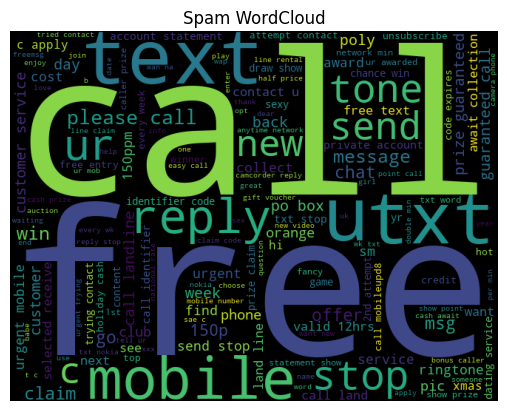

In [9]:
# most frequent words are in samp 
spam_wc = wc.generate(
    data[data['target']==1]['process_text'].str.cat(sep=" ")
)
# display
plt.imshow(spam_wc)
plt.axis('off')
plt.title("Spam WordCloud")
plt.show()

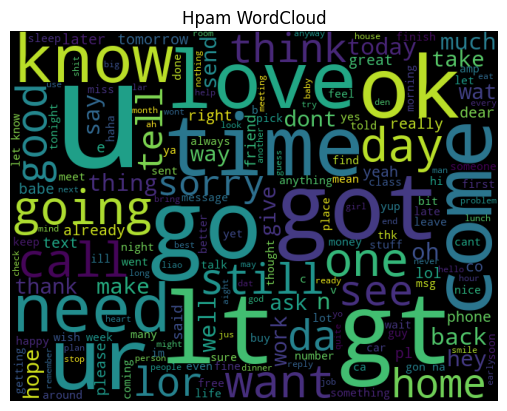

In [10]:
# most frequent words are in hamp 
spam_wc = wc.generate(
    data[data['target']==0]['process_text'].str.cat(sep=" ")
)
# display
plt.imshow(spam_wc)
plt.axis('off')
plt.title("Hpam WordCloud")
plt.show()

In [11]:
spam_corpus = []
for msg in data[data['target']==1]['process_text'].tolist():
    for word in msg.split():
        spam_corpus.append(word)
# check its length
len(spam_corpus)

9936

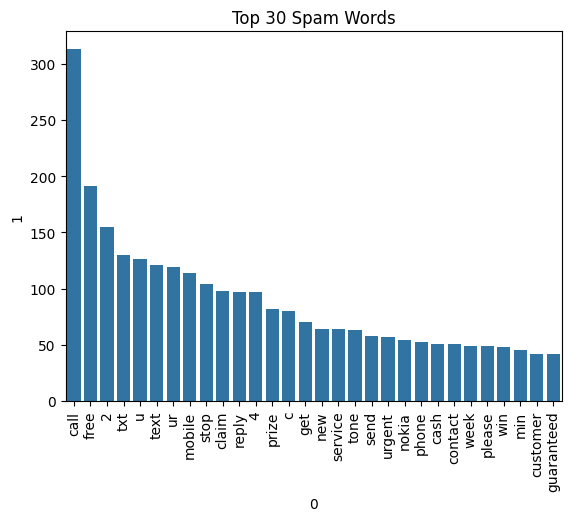

In [12]:
import seaborn as sns
from collections import Counter
# get top 30 words
top_words = pd.DataFrame(Counter(spam_corpus).most_common(30))

# plot
sns.barplot(x=top_words[0], y=top_words[1])

plt.xticks(rotation='vertical')
plt.title("Top 30 Spam Words")
plt.show()

In [13]:
#hamp
hpam_corpus = []
for msg in data[data['target']==0]['process_text'].tolist():
    for word in msg.split():
        hpam_corpus.append(word)
# check its length
len(hpam_corpus)

35305

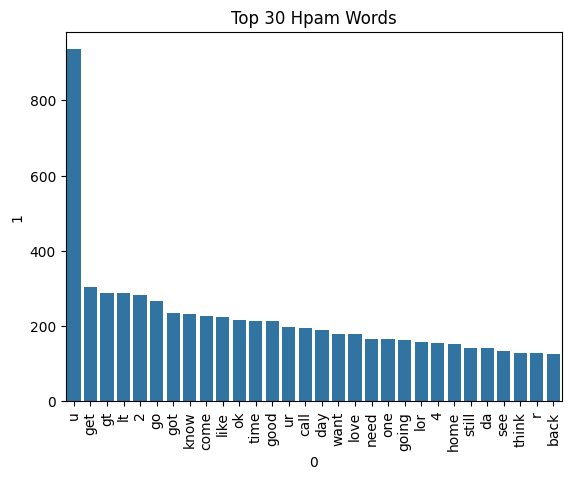

In [14]:
from collections import Counter
# get top 30 words
top_words = pd.DataFrame(Counter(hpam_corpus).most_common(30))

# plot
sns.barplot(x=top_words[0], y=top_words[1])

plt.xticks(rotation='vertical')
plt.title("Top 30 Hpam Words")
plt.show()

In [15]:
df = data.copy()


# Model Creaction And Selection


## First Attempt: Model Training & Comparison

In [16]:
from sklearn.feature_extraction.text import TfidfVectorizer ,CountVectorizer
cv = CountVectorizer()
tfidf = TfidfVectorizer(max_features=3000)

In [17]:
# X and y 
X= tfidf.fit_transform(data['process_text']).toarray()

y = data['target'].values


In [18]:
X.shape

(5169, 3000)

In [19]:
y

array([0, 0, 1, ..., 0, 0, 0], shape=(5169,))

In [20]:
# split the data
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=2)

In [21]:
from sklearn.metrics import accuracy_score,precision_score,confusion_matrix


In [22]:
from sklearn.naive_bayes import GaussianNB,MultinomialNB,BernoulliNB
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import BaggingClassifier,AdaBoostClassifier,GradientBoostingClassifier
from xgboost import XGBClassifier

In [23]:
bnb = BernoulliNB()
mnb = MultinomialNB()
gnb = GaussianNB()
lr = LogisticRegression()
sv  = SVC()
dtc = DecisionTreeClassifier()
rfc = RandomForestClassifier()
bagging = BaggingClassifier()
adaboost = AdaBoostClassifier()
gbc = GradientBoostingClassifier()

In [24]:
models={
    'Gaussian_NB':gnb,
    'Bernoulli_NB':bnb,
    'Multinomial_NB':mnb,
    'Logistic_Regression':lr,
    'SVC':sv,
    'DecisionTreeClassifier':dtc,
    'RandomForestClassifier':rfc,
    'BaggingClassifier':bagging,
    'AdaBoostClassifier':adaboost,
    'GradientBoostingClassifier':gbc
}

def model_training(model,X_train,y_train,X_test,y_test):
    model.fit(X_train,y_train)
    y_pred = model.predict(X_test)
    accuracy = accuracy_score(y_test,y_pred)
    precision = precision_score(y_test,y_pred)
 
    
    return accuracy,precision

In [25]:
model_training(sv,X_train,y_train,X_test,y_test)

(0.9748549323017408, 0.9912280701754386)

In [26]:
model_training(bnb,X_train,y_train,X_test,y_test)


(0.9845261121856866, 1.0)

In [27]:
accuracy_scores = []
precision_scores = []

for name,model in models.items():
    
    current_accuracy,current_precision = model_training(model, X_train,y_train,X_test,y_test)
    
    print("For ",name)
    print("Accuracy - ",current_accuracy)
    print("Precision - ",current_precision)
    
    accuracy_scores.append(current_accuracy)
    precision_scores.append(current_precision)

For  Gaussian_NB
Accuracy -  0.8810444874274661
Precision -  0.5345622119815668
For  Bernoulli_NB
Accuracy -  0.9845261121856866
Precision -  1.0
For  Multinomial_NB
Accuracy -  0.9738878143133463
Precision -  1.0
For  Logistic_Regression
Accuracy -  0.9535783365570599
Precision -  0.9891304347826086
For  SVC
Accuracy -  0.9748549323017408
Precision -  0.9912280701754386
For  DecisionTreeClassifier
Accuracy -  0.9506769825918762
Precision -  0.8129496402877698
For  RandomForestClassifier
Accuracy -  0.9758220502901354
Precision -  0.9829059829059829
For  BaggingClassifier
Accuracy -  0.9584139264990329
Precision -  0.8740157480314961
For  AdaBoostClassifier
Accuracy -  0.9235976789168279
Precision -  0.8641975308641975
For  GradientBoostingClassifier
Accuracy -  0.9613152804642167
Precision -  0.9454545454545454


In [28]:
performance_daraframe = pd.DataFrame({'Algorithm':models.keys(),'Accuracy':accuracy_scores,'Precision':precision_scores}).sort_values('Precision',ascending=False)

In [29]:
performance_daraframe

,Algorithm,Accuracy,Precision
1,Bernoulli_NB,0.984526,1.000000
2,Multinomial_NB,0.973888,1.000000
4,SVC,0.974855,0.991228
3,Logistic_Regression,0.953578,0.989130
6,RandomForestClassifier,0.975822,0.982906
9,GradientBoostingClassifier,0.961315,0.945455
7,BaggingClassifier,0.958414,0.874016
8,AdaBoostClassifier,0.923598,0.864198
5,DecisionTreeClassifier,0.950677,0.812950
0,Gaussian_NB,0.881044,0.534562


C:\Users\Avik Maity\AppData\Local\Temp\ipykernel_7028\2549447439.py:38: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


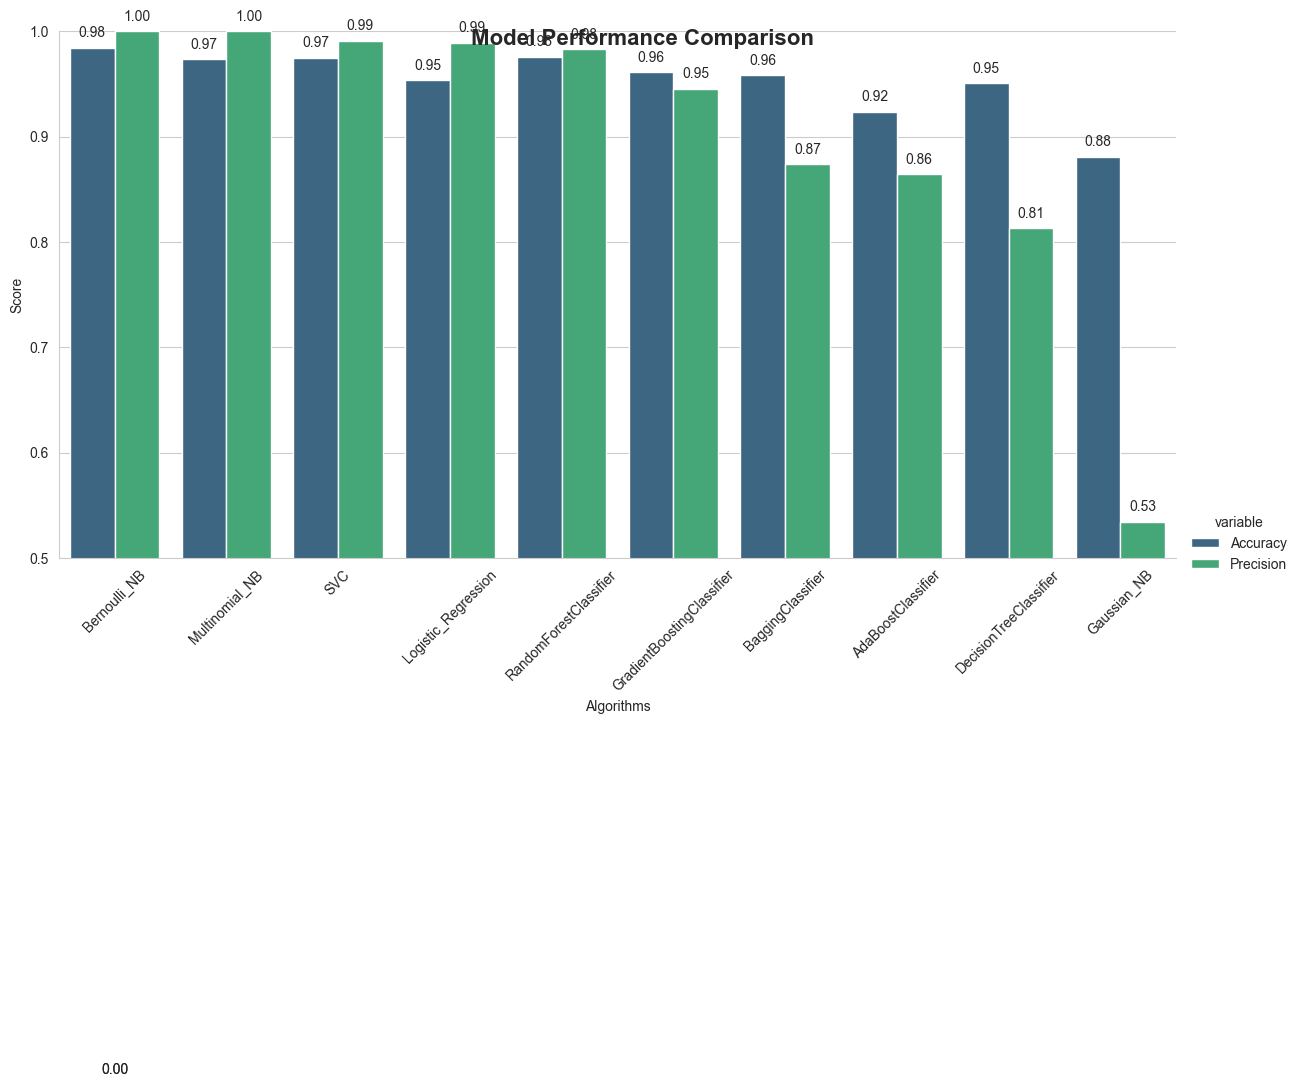

In [30]:
performance_df = pd.melt(performance_daraframe, id_vars = "Algorithm")

import seaborn as sns
import matplotlib.pyplot as plt

sns.set_style("whitegrid")  

g = sns.catplot(
    x='Algorithm',
    y='value',
    hue='variable',
    data=performance_df,
    kind='bar',
    height=6,
    aspect=2,
    palette='viridis'
)

g.fig.suptitle("Model Performance Comparison", fontsize=16, fontweight='bold')

g.set_axis_labels("Algorithms", "Score")

plt.xticks(rotation=45)

plt.ylim(0.5, 1.0)

# Add value labels on bars
for ax in g.axes.flat:
    for p in ax.patches:
        height = p.get_height()
        ax.text(
            p.get_x() + p.get_width() / 2,
            height + 0.01,
            f"{height:.2f}",
            ha="center"
        )

plt.tight_layout()
plt.show()

# Model evaluation

In [31]:
# model improve
# 1. Change the max_features parameter of TfIdf fromm 1000 to 3000
# test size 5 to 2

In [32]:
from sklearn.ensemble import VotingClassifier
from sklearn.ensemble import ExtraTreesClassifier
# Voting Classifier
svc = SVC(kernel='sigmoid', gamma=1.0,probability=True)
mnb = MultinomialNB()
etc = ExtraTreesClassifier(n_estimators=50, random_state=2)
voting = VotingClassifier(estimators=[('svm', svc), ('nb', bnb), ('et', etc)],voting='soft')
voting.fit(X_train,y_train)

,"estimators estimators: list of (str, estimator) tuplesInvoking the ``fit`` method on the ``VotingClassifier`` will fit clonesof those original estimators that will be stored in the class attribute``self.estimators_``. An estimator can be set to ``'drop'`` using:meth:`set_params`... versionchanged:: 0.21 ``'drop'`` is accepted. Using None was deprecated in 0.22 and support was removed in 0.24.","[('svm', ...), ('nb', ...), ...]"
,"voting voting: {'hard', 'soft'}, default='hard'If 'hard', uses predicted class labels for majority rule voting.Else if 'soft', predicts the class label based on the argmax ofthe sums of the predicted probabilities, which is recommended foran ensemble of well-calibrated classifiers.",'soft'
,"weights weights: array-like of shape (n_classifiers,), default=NoneSequence of weights (`float` or `int`) to weight the occurrences ofpredicted class labels (`hard` voting) or class probabilitiesbefore averaging (`soft` voting). Uses uniform weights if `None`.",None
,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel for ``fit``.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionadded:: 0.18",None
,"flatten_transform flatten_transform: bool, default=TrueAffects shape of transform output only when voting='soft'If voting='soft' and flatten_transform=True, transform method returnsmatrix with shape (n_samples, n_classifiers * n_classes). Ifflatten_transform=False, it returns(n_classifiers, n_samples, n_classes).",True
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting will be printed as itis completed... versionadded:: 0.23",False
,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive. The penaltyis a squared l2 penalty. For an intuitive visualization of the effectsof scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",1.0
,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm. Ifnone is given, 'rbf' will be used. If a callable is given it is used topre-compute the kernel matrix from data matrices; that matrix should bean array of shape ``(n_samples, n_samples)``. For an intuitivevisualization of different kernel types see:ref:`sphx_glr_auto_examples_svm_plot_svm_kernels.py`.",'sigmoid'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",1.0
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0


In [33]:
# voting
y_pred = voting.predict(X_test)
print("Accuracy",accuracy_score(y_test,y_pred))
print("Precision",precision_score(y_test,y_pred))

Accuracy 0.9854932301740812
Precision 1.0


In [34]:
# Applying stacking
from sklearn.ensemble import StackingClassifier
estimators=[('svm', svc), ('nb', bnb), ('et', etc)]
final_estimator=RandomForestClassifier()

In [35]:
stack_model = StackingClassifier(estimators=estimators, final_estimator=final_estimator)
stack_model.fit(X_train,y_train)
y_pred = stack_model.predict(X_test)
print("Accuracy",accuracy_score(y_test,y_pred))
print("Precision",precision_score(y_test,y_pred))

Accuracy 0.9835589941972921
Precision 0.9689922480620154


In [38]:
import pickle
import os

# Create folder 
os.makedirs("../artifacts", exist_ok=True)

# Save vectorizer
with open("../artifacts/vectorizer.pkl", "wb") as f:
    pickle.dump(tfidf, f)

# Save model bnb
with open("../artifacts/model.pkl", "wb") as f:
    pickle.dump(voting, f)